<a href="https://colab.research.google.com/github/Phalguni-dhabale/PR-LAB/blob/main/PR_PRACTICAL_4_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = {
    'Age':[25,35,45,32,23,52,40,28,36,48],
    'Income':[30000,50000,70000,45000,25000,90000,65000,38000,58000,80000],
    'CreditScore':[650,700,750,680,620,800,730,690,710,780],
    'LoanAmount':[100000,150000,200000,120000,90000,250000,180000,110000,160000,220000],
    'Employment':['No','Yes','Yes','Yes','No','Yes','Yes','No','Yes','Yes'],
    'LoanApproved':['No','Yes','Yes','Yes','No','Yes','Yes','No','Yes','Yes']
}

df = pd.DataFrame(data)

df.head()

,Age,Income,CreditScore,LoanAmount,Employment,LoanApproved
0,25,30000,650,100000,No,No
1,35,50000,700,150000,Yes,Yes
2,45,70000,750,200000,Yes,Yes
3,32,45000,680,120000,Yes,Yes
4,23,25000,620,90000,No,No


In [3]:
encoder = LabelEncoder()

df['Employment'] = encoder.fit_transform(df['Employment'])
df['LoanApproved'] = encoder.fit_transform(df['LoanApproved'])

df.head()

,Age,Income,CreditScore,LoanAmount,Employment,LoanApproved
0,25,30000,650,100000,0,0
1,35,50000,700,150000,1,1
2,45,70000,750,200000,1,1
3,32,45000,680,120000,1,1
4,23,25000,620,90000,0,0


In [4]:
X = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
dt_pred = dt.predict(X_test)

In [9]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 1.0
[[2]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


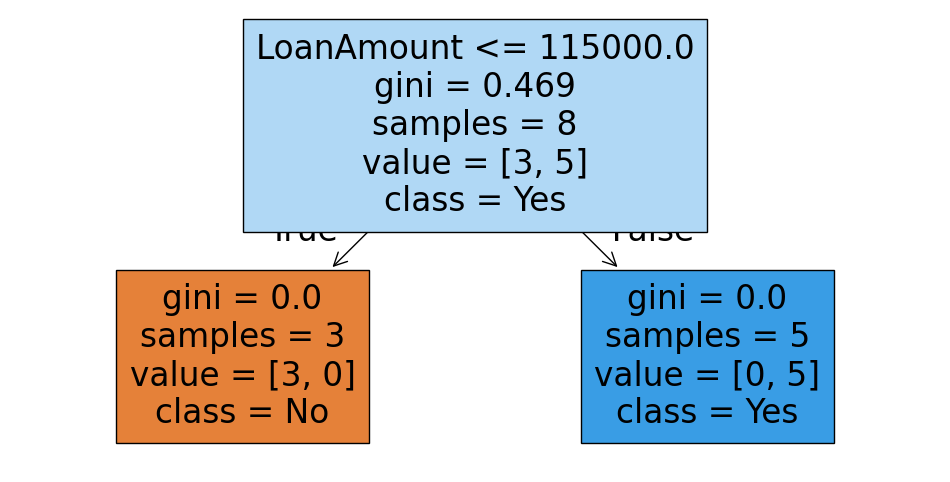

In [10]:
plt.figure(figsize=(12,6))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

In [11]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
knn_pred = knn.predict(X_test_scaled)

In [13]:
print("K-NN Accuracy:",
      accuracy_score(y_test, knn_pred))

print(confusion_matrix(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

K-NN Accuracy: 1.0
[[2]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [14]:
dt_accuracy = accuracy_score(y_test, dt_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)

print("Decision Tree Accuracy :", dt_accuracy)
print("K-NN Accuracy :", knn_accuracy)

Decision Tree Accuracy : 1.0
K-NN Accuracy : 1.0
